# **City Landscape in Sight: A Crowdsourced Framework for Unlocking Urban-Scale Window View Perceptions from Real Estate Imagery**

**Authors:** [Chucai Peng](https://ual.sg/author/chucai-peng/)†, [Sijie Yang](https://sijie-yang.com)†, Ang Liu, Yang Xiang, Zhixiang Zhou, [Filip Biljecki](https://filipbiljecki.com)* 

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)


---

(† co-first authors, * corresponding authors)

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# Code_1_Perception Survey Results

This notebook processes the crowdsourced perception survey (Methods §2.2): it loads pairwise comparison records, aggregates them with the [TrueSkill](https://trueskill.org) Bayesian rating system, inspects the resulting per-image scores, and merges them with visual features (from **Code 2**) to build the training tables used in **Code 3**.

**Pipeline:** `raw/` → TrueSkill → `ranked/` (μ, σ, `Score_10`) → rank-spread **0–5** `Score` → merge with `Features.csv` → `training_features/`

Data paths:
- **Input:** `data/perception_survey/raw/{dimension}.csv` (pairwise comparisons)
- **Input:** `data/training_features/Features.csv` (per-image visual features from Code 2)
- **Output:** `data/perception_survey/ranked/ranked_{dimension}.csv` (μ, σ, `Score_10`, 0–5 `Score`)
- **Output:** `data/training_features/TrainingFeatures_{dimension}.csv` (features + 0–5 perception score)

## 0. Plotting Configuration

Run plotting configuration first — set up the overall style of figures.

In [1]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=0.9)

mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "figure.autolayout": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.linewidth": 0.6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Okabe–Ito colorblind-safe palette
OKABE_ITO = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermilion
    "#CC79A7",  # reddish purple
    "#000000",  # black
]
sns.set_palette(OKABE_ITO)

# Six perception dimensions used throughout the project
PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
PERCEPTION_DIMS_TITLE = [d.capitalize() for d in PERCEPTION_DIMS]
perception_colors = {d: OKABE_ITO[i % len(OKABE_ITO)] for i, d in enumerate(PERCEPTION_DIMS)}

# Figure sizing aligned to Nature formats
INCH_PER_MM = 1.0 / 25.4
COL_WIDTH = 89 * INCH_PER_MM
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_SMALL = 2.2
FIG_HEIGHT_MEDIUM = 2.8
FIG_HEIGHT_TALL = 3.4

def savefig_all(fig, basename, png_dpi=300, tight=True):
    """Save figure to PNG and SVG with consistent settings."""
    out_base = Path(basename)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)

## 1. Pairwise Survey Records

Each respondent saw two window-view images side by side and selected the one that better matched the queried perception (e.g. *which view feels more oppressive?*). For each dimension, all pairwise outcomes are stored in `data/perception_survey/raw/{dimension}.csv` with columns `Image 1`, `Image 2`, and `Selected Image`.

#### load aggregated pairwise records

In [3]:
import os
import pandas as pd

RAW_DIR = Path("data/perception_survey/raw/")
RANKED_DIR = Path("data/perception_survey/ranked")
FEATURES_DIR = Path("data/training_features")
RANKED_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

pairwise = {dim: pd.read_csv(RAW_DIR / f"{dim}.csv") for dim in PERCEPTION_DIMS}

summary_rows = []
for dim, df in pairwise.items():
    n_pairs = len(df)
    n_unique = pd.unique(df[["Image 1", "Image 2"]].values.ravel()).size
    summary_rows.append({
        "dimension": dim,
        "n_pairwise_comparisons": n_pairs,
        "n_unique_images": n_unique,
    })

summary_df = pd.DataFrame(summary_rows).set_index("dimension")
print("Pairwise survey summary:")
print(summary_df.to_string())
print(f"\nTotal pairwise comparisons: {summary_df['n_pairwise_comparisons'].sum()}")

print("\nSample of raw pairwise records (oppressive):")
print(pairwise["oppressive"].head().to_string(index=False))

Pairwise survey summary:
            n_pairwise_comparisons  n_unique_images
dimension                                          
prefer                        4622              499
monotonous                    4516              499
quiet                         4649              499
extensive                     4598              499
vivid                         4404              499
oppressive                    4688              499

Total pairwise comparisons: 27477

Sample of raw pairwise records (oppressive):
         Image 1          Image 2   Selected Image
104108647249.jpg 104108997771.jpg 104108997771.jpg
104108592506.jpg 104107250587.jpg 104107250587.jpg
104108910520.jpg 104108920555.jpg 104108920555.jpg
104108041370.jpg 104108251388.jpg 104108041370.jpg
104108858221.jpg 104109052464.jpg 104108858221.jpg


## 2. TrueSkill Ranking

[TrueSkill](https://trueskill.org) models each image as a Gaussian rating $\mathcal{N}(\mu, \sigma^2)$ and updates both parameters after every 1‑vs‑1 outcome. After processing all pairwise comparisons for a dimension, $\mu$ is min–max scaled to a 0–10 perception `Score`, which becomes the regression target for Code 3. Results are written to `data/perception_survey/ranked/ranked_{dimension}.csv`.

In [4]:
import trueskill as ts

def rank_with_trueskill(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate pairwise outcomes into per-image TrueSkill ratings."""
    env = ts.TrueSkill()
    ratings = {}
    for _, row in pairwise_df.iterrows():
        a, b, picked = row["Image 1"], row["Image 2"], row["Selected Image"]
        ratings.setdefault(a, env.create_rating())
        ratings.setdefault(b, env.create_rating())
        if picked == a:
            ratings[a], ratings[b] = env.rate_1vs1(ratings[a], ratings[b])
        else:
            ratings[b], ratings[a] = env.rate_1vs1(ratings[b], ratings[a])

    sorted_items = sorted(ratings.items(), key=lambda kv: kv[1].mu, reverse=True)
    df = pd.DataFrame(
        [(img, r.mu, r.sigma) for img, r in sorted_items],
        columns=["Image", "Mu", "Sigma"],
    )
    mu_min, mu_max = df["Mu"].min(), df["Mu"].max()
    df["Score"] = 10.0 * (df["Mu"] - mu_min) / (mu_max - mu_min)
    return df

ranked = {}
for dim in PERCEPTION_DIMS:
    df = rank_with_trueskill(pairwise[dim])
    df.to_csv(RANKED_DIR / f"ranked_{dim}.csv", index=False)
    ranked[dim] = df
    print(
        f"{dim:<11} | n_images={len(df):4d} | mu=[{df['Mu'].min():.2f}, {df['Mu'].max():.2f}] "
        f"| sigma_mean={df['Sigma'].mean():.3f}"
    )

print("\nTop 5 oppressive views:")
print(ranked["oppressive"].head().to_string(index=False))

prefer      | n_images= 499 | mu=[4.77, 44.01] | sigma_mean=3.073
monotonous  | n_images= 499 | mu=[4.74, 44.68] | sigma_mean=3.099
quiet       | n_images= 499 | mu=[5.20, 44.71] | sigma_mean=3.021
extensive   | n_images= 499 | mu=[5.48, 45.01] | sigma_mean=3.051
vivid       | n_images= 499 | mu=[5.19, 45.05] | sigma_mean=3.161
oppressive  | n_images= 499 | mu=[4.36, 45.50] | sigma_mean=3.067

Top 5 oppressive views:
           Image        Mu    Sigma     Score
104108794974.jpg 45.504008 3.058499 10.000000
104108947440.jpg 45.273183 2.901941  9.943904
104108403161.jpg 44.870238 2.722936  9.845980
104108753924.jpg 44.843403 3.107871  9.839459
104109008763.jpg 43.664060 3.219406  9.552853


## 3. Survey Score Distributions

#### distribution — TrueSkill score by perception dimension

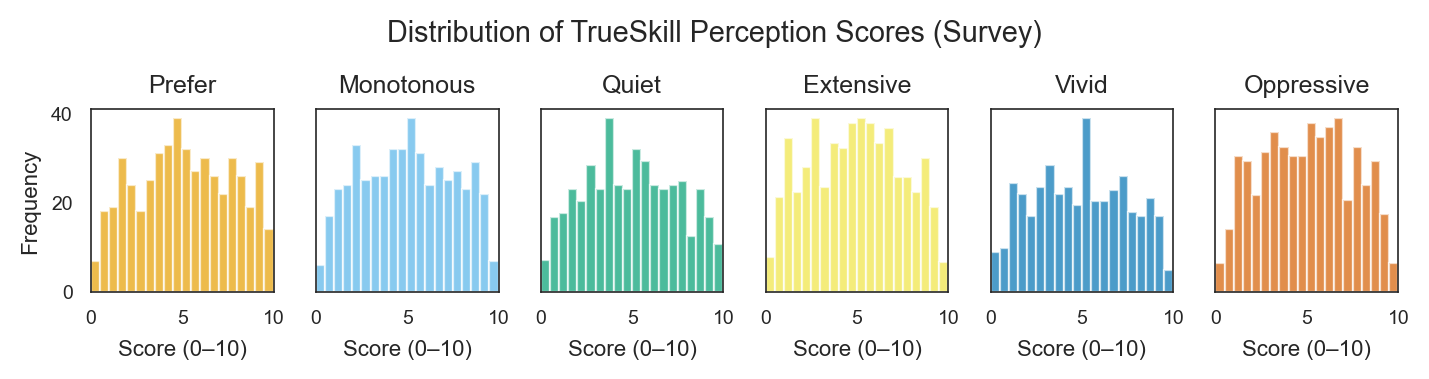

In [5]:
fig, axes = plt.subplots(1, 6, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_SMALL))
fig.suptitle("Distribution of TrueSkill Perception Scores (Survey)", y=0.85)

for ax, dim in zip(axes, PERCEPTION_DIMS):
    ax.hist(ranked[dim]["Score"], bins=20, alpha=0.7, color=perception_colors[dim])
    ax.set_title(dim.capitalize())
    ax.set_xlabel("Score (0–10)")
    ax.set_xlim(0, 10)
    ax.set_box_aspect(1)
axes[0].set_ylabel("Frequency")
for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=False)

plt.tight_layout()
savefig_all(fig, "figures/code1_truescore_distribution")
plt.show()

#### rank-based 0–5 training scores

TrueSkill `Score` on [0, 10] is retained as `Score_10`. For model training (Methods: continuous perception scores on a 1–5 scale), we **re-map by rank**: sort images by `Score_10`, assign evenly spaced targets on **[0, 5]** (lowest → 0, highest → 5), and write the result back to `ranked/` and `TrainingFeatures_{dimension}.csv`.

[prefer] method=rank_spread | Score_10 [0.00, 10.00] → Score_0_5 [0.00, 5.00] | wrote ranked + TrainingFeatures (499/499)
[monotonous] method=rank_spread | Score_10 [0.00, 10.00] → Score_0_5 [0.00, 5.00] | wrote ranked + TrainingFeatures (499/499)
[quiet] method=rank_spread | Score_10 [0.00, 10.00] → Score_0_5 [0.00, 5.00] | wrote ranked + TrainingFeatures (499/499)
[extensive] method=rank_spread | Score_10 [0.00, 10.00] → Score_0_5 [0.00, 5.00] | wrote ranked + TrainingFeatures (499/499)
[vivid] method=rank_spread | Score_10 [0.00, 10.00] → Score_0_5 [0.00, 5.00] | wrote ranked + TrainingFeatures (499/499)
[oppressive] method=rank_spread | Score_10 [0.00, 10.00] → Score_0_5 [0.00, 5.00] | wrote ranked + TrainingFeatures (499/499)


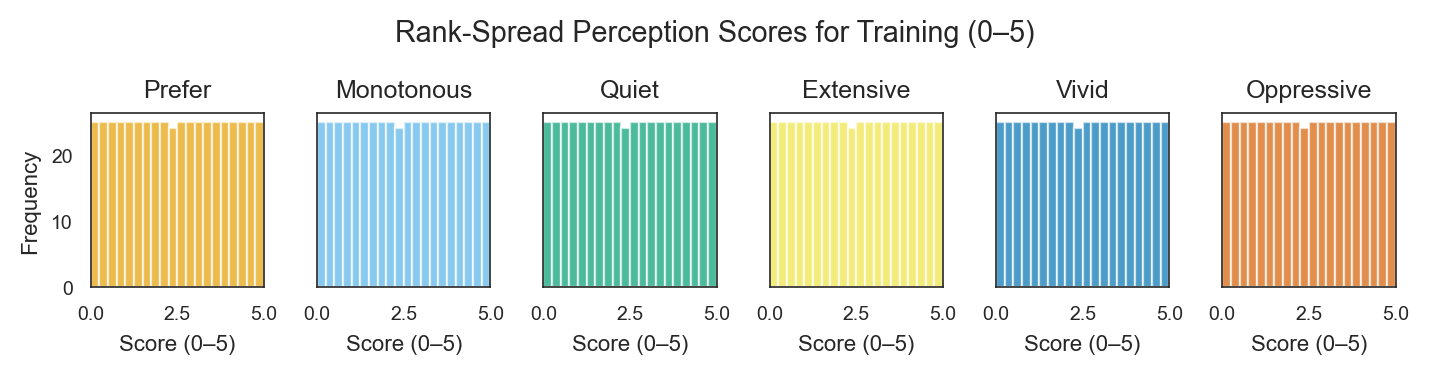

In [6]:
WINSOR_LOWER_Q = 0.05
WINSOR_UPPER_Q = 0.95
SIGMA_WEIGHT_POWER = 2.0  # w ∝ (σ_med / σ)^power; 2 ≈ inverse-variance
SCORE_TARGET_METHOD = "rank_spread"  # rank_spread | winsorize_linear | winsorize_linear_sigma


def sigma_confidence_weights(
    sigma: pd.Series,
    power: float = SIGMA_WEIGHT_POWER,
    eps: float = 1e-6,
) -> pd.Series:
    """Lower TrueSkill σ → higher weight (normalized to mean 1)."""
    ref = float(sigma.median())
    w = (ref / sigma.astype(float).clip(lower=eps)) ** power
    return w / w.mean()


def weighted_quantile(values: pd.Series, weights: pd.Series, q: float) -> float:
    """Weighted quantile via cumulative weight (q in [0, 1])."""
    v = values.astype(float).to_numpy()
    w = weights.astype(float).to_numpy()
    if len(v) == 0:
        return float("nan")
    order = np.argsort(v)
    v, w = v[order], w[order]
    cw = np.cumsum(w)
    if cw[-1] <= 0:
        return float(np.quantile(v, q))
    cw /= cw[-1]
    return float(np.interp(q, cw, v))


def spread_score_0_5_by_rank(scores: pd.Series) -> pd.Series:
    """Evenly spread ranks onto [0, 5]: lowest score → 0, highest → 5."""
    n = len(scores)
    if n <= 1:
        return pd.Series([2.5] * n, index=scores.index, dtype=float)
    ranks = scores.rank(method="average", ascending=True)
    return 5.0 * (ranks - 1) / (n - 1)


def winsorize_linear_scale_0_5(
    scores: pd.Series,
    lower_q: float = WINSOR_LOWER_Q,
    upper_q: float = WINSOR_UPPER_Q,
    weights: pd.Series | None = None,
) -> pd.Series:
    """Clip at lower/upper quantiles, then linearly scale clipped values to [0, 5]."""
    if weights is None:
        lo = float(scores.quantile(lower_q))
        hi = float(scores.quantile(upper_q))
    else:
        lo = weighted_quantile(scores, weights, lower_q)
        hi = weighted_quantile(scores, weights, upper_q)
    clipped = scores.astype(float).clip(lower=lo, upper=hi)
    if hi <= lo:
        return pd.Series([2.5] * len(scores), index=scores.index, dtype=float)
    return 5.0 * (clipped - lo) / (hi - lo)


def map_score_0_5(
    scores: pd.Series,
    method: str = SCORE_TARGET_METHOD,
    sigma: pd.Series | None = None,
) -> pd.Series:
    if method == "rank_spread":
        return spread_score_0_5_by_rank(scores)
    if method == "winsorize_linear":
        return winsorize_linear_scale_0_5(scores)
    if method == "winsorize_linear_sigma":
        if sigma is None:
            raise ValueError("winsorize_linear_sigma requires sigma")
        w = sigma_confidence_weights(sigma)
        return winsorize_linear_scale_0_5(scores, weights=w)
    raise ValueError(f"Unknown SCORE_TARGET_METHOD: {method!r}")


features_base = pd.read_csv(FEATURES_DIR / "Features.csv")
features_base["ID"] = features_base["ID"].astype(str)
drop_cols = [c for c in PERCEPTION_DIMS if c in features_base.columns]
if drop_cols:
    features_base = features_base.drop(columns=drop_cols)

for dim in PERCEPTION_DIMS:
    df = ranked[dim].copy()
    df["Score_10"] = df["Score"]
    df["Score"] = map_score_0_5(df["Score_10"], method=SCORE_TARGET_METHOD)
    ranked[dim] = df
    df.to_csv(RANKED_DIR / f"ranked_{dim}.csv", index=False)

    sub = df[["Image", "Score"]].copy()
    sub["ID"] = sub["Image"].str.replace(".jpg", "", regex=False).astype(str)
    sub = sub.rename(columns={"Score": dim})[["ID", dim]]
    merged = features_base.merge(sub, on="ID", how="left")
    cols = merged.columns.tolist()
    cols.remove(dim)
    cols.insert(1, dim)
    merged = merged[cols]
    merged.to_csv(FEATURES_DIR / f"TrainingFeatures_{dim}.csv", index=False)
    print(
        f"[{dim}] method={SCORE_TARGET_METHOD} | Score_10 [{df['Score_10'].min():.2f}, {df['Score_10'].max():.2f}] "
        f"→ Score_0_5 [{df['Score'].min():.2f}, {df['Score'].max():.2f}] "
        f"| wrote ranked + TrainingFeatures ({merged[dim].notna().sum()}/499)"
    )

fig, axes = plt.subplots(1, 6, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_SMALL))
fig_title = (
    "Rank-Spread Perception Scores for Training (0–5)"
    if SCORE_TARGET_METHOD == "rank_spread"
    else f"Training Scores (0–5) — {SCORE_TARGET_METHOD}"
)
fig.suptitle(fig_title, y=0.85)
for ax, dim in zip(axes, PERCEPTION_DIMS):
    ax.hist(ranked[dim]["Score"], bins=20, alpha=0.7, color=perception_colors[dim])
    ax.set_title(dim.capitalize())
    ax.set_xlabel("Score (0–5)")
    ax.set_xlim(0, 5)
    ax.set_box_aspect(1)
axes[0].set_ylabel("Frequency")
for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=False)
plt.tight_layout()
fig_name = (
    "figures/code1_score05_winsor_linear_distribution"
    if SCORE_TARGET_METHOD == "winsorize_linear"
    else "figures/code1_score05_rankspread_distribution"
)
savefig_all(fig, fig_name)
plt.show()

#### sigma diagnostics — rating uncertainty

/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_24974/2131154283.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(PERCEPTION_DIMS_TITLE, rotation=20, ha="right")


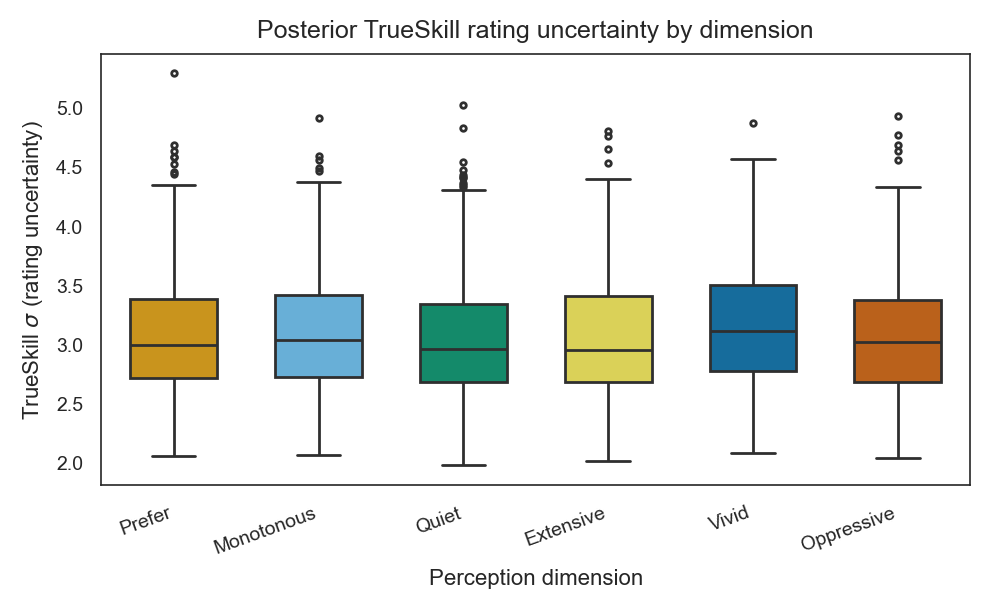


Mean sigma per dimension (lower = more confident):
prefer        3.072933
monotonous    3.099337
quiet         3.021426
extensive     3.051031
vivid         3.161474
oppressive    3.067339


In [7]:
sigma_df = pd.DataFrame({dim: ranked[dim]["Sigma"].values for dim in PERCEPTION_DIMS})

fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.6, FIG_HEIGHT_MEDIUM))
sns.boxplot(data=sigma_df, ax=ax, palette=[perception_colors[d] for d in PERCEPTION_DIMS], width=0.6, fliersize=2)
ax.set_ylabel("TrueSkill $\\sigma$ (rating uncertainty)")
ax.set_xlabel("Perception dimension")
ax.set_xticklabels(PERCEPTION_DIMS_TITLE, rotation=20, ha="right")
ax.set_title("Posterior TrueSkill rating uncertainty by dimension")
savefig_all(fig, "figures/code1_truescore_sigma")
plt.show()

print("\nMean sigma per dimension (lower = more confident):")
print(sigma_df.mean().to_string())

#### cross-dimension correlation

Joining the six ranked tables on `Image` lets us check how the perception dimensions relate to each other.

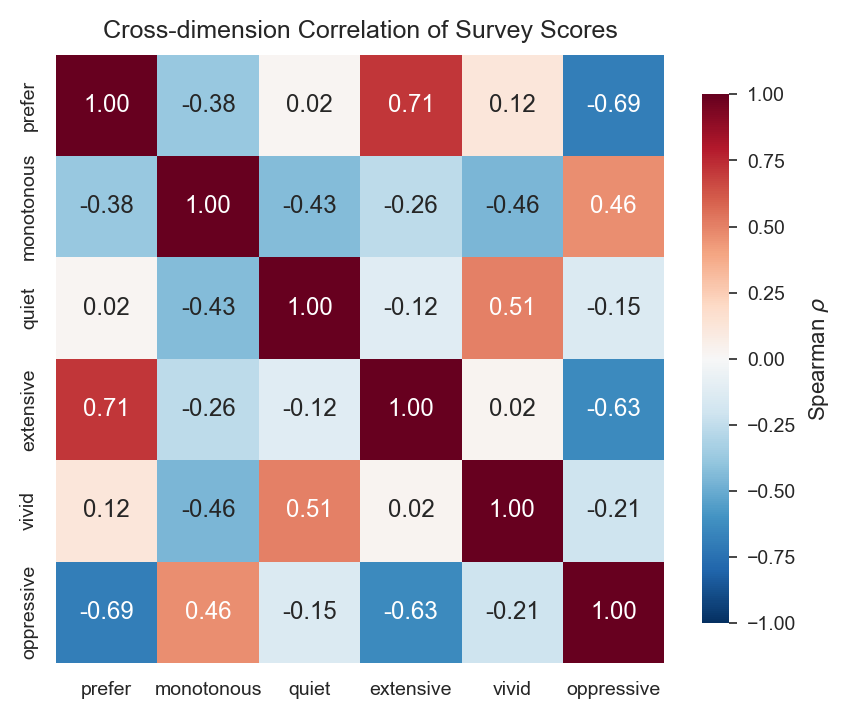


Survey score table preview:
          ID   prefer  monotonous    quiet  extensive    vivid  oppressive
104104481434 3.965863    2.008032 2.610442   2.178715 1.987952    2.188755
104105588631 2.690763    2.168675 1.224900   4.608434 0.210843    0.532129
104105683403 0.702811    3.032129 3.795181   2.208835 4.748996    2.941767
104105980871 3.303213    2.118474 4.287149   4.267068 1.917671    0.431727
104106057649 2.369478    1.536145 4.879518   3.293173 4.789157    3.092369


In [8]:
score_wide = None
for dim in PERCEPTION_DIMS:
    sub = ranked[dim][["Image", "Score"]].rename(columns={"Score": dim})
    score_wide = sub if score_wide is None else score_wide.merge(sub, on="Image", how="outer")

score_wide["ID"] = score_wide["Image"].str.replace(".jpg", "", regex=False)
score_wide = score_wide[["ID"] + PERCEPTION_DIMS]

corr = score_wide[PERCEPTION_DIMS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.4, COL_WIDTH * 1.4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"shrink": 0.7, "label": "Spearman $\\rho$"})
ax.set_title("Cross-dimension Correlation of Survey Scores")
savefig_all(fig, "figures/code1_truescore_correlation")
plt.show()

print("\nSurvey score table preview:")
print(score_wide.head().to_string(index=False))

## 4. Training Feature Tables (preview)

Per-dimension `TrainingFeatures_{dimension}.csv` files were written in §3 (rank-spread 0–5 scores merged with `Features.csv`). The cell below reloads one table for inspection.

In [9]:
preview = pd.read_csv(FEATURES_DIR / "TrainingFeatures_oppressive.csv")
print(f"TrainingFeatures_oppressive.csv — shape = {preview.shape}")
print(
    f"  {preview['oppressive'].name}: min={preview['oppressive'].min():.3f}, "
    f"max={preview['oppressive'].max():.3f} (expect 0–5 rank-spread targets)"
)
print("\nPreview:")
print(preview.head().to_string(index=False))

TrainingFeatures_oppressive.csv — shape = (499, 26)
  oppressive: min=0.000, max=5.000 (expect 0–5 rank-spread targets)

Preview:
          ID  oppressive    Sky  High rise building  Low rise building  Grass  Hard ground   Tree  Water  Railing   Road  Barren land  Building interior  Floor  Hue_Mean   Hue_Std  Saturation_Mean  Saturation_Std  Brightness_Mean  Brightness_Std  EdgePixelRatio  Entropy  Colorfulness   Contrast   Sharpness  Image_Variance
104104481434    2.188755 0.0906              0.0432             0.0005 0.0950       0.0172 0.0179 0.0000   0.0284 0.0000          0.0             0.7072      1 19.970012 33.481926        18.613041       43.687021       104.247326      113.993436       14.688552 4.287161     18.788781 112.215723 1389.503668    12592.368483
104105588631    0.532129 0.1422              0.1169             0.0257 0.0000       0.0143 0.0359 0.0000   0.1679 0.0031          0.0             0.4939      3 67.019651 53.125186        43.092398       76.651327       100

**Summary.** We loaded pairwise survey records from `raw/`, ran TrueSkill to obtain per-image ratings in `ranked/` (`Score_10` on 0–10), mapped ranks to evenly spaced **0–5** training targets, and merged them with `Features.csv` (Code 2) into `TrainingFeatures_*.csv`. **Code 3** uses these tables to train a CNN + features regression model that generalises to the city-wide WVI dataset.